# BIOT 6900 · Module 3 Assignment: Target Triage with Protein Language Models

**Computational Lab 3 · 100 points · due Thursday, October 8 at 6:00 pm**

Apply the Module 3 method to **your own targets from Module 2**, whichever disease you studied. Follow the assignment sheet: each step below matches a numbered step there. Complete every cell marked **TODO**. Helper functions from Part 2 are provided so you can focus on the analysis.

**Data pack:** no data pack was posted on Canvas, so `data/` was built with `scripts/build_data_pack.py` from my Module 2 output plus UniProt, Open Targets and HGNC (see README).

**Before you start:** complete lab Parts 1 and 2; build or unzip the Module 3 data pack into `data/`; put your Module 2 target file (for example `targets_ad.csv`) next to this notebook.

**Before you submit:** Kernel → Restart & Run All, and check that every cell runs.

In [1]:
# ---------------- YOUR SETTINGS ----------------
TARGETS_FILE = "targets_ad.csv"   # TODO: your Module 2 output, e.g. targets_ad.csv or targets_<disease>.csv
DISEASE      = "ad"               # TODO: short name used in the output file name, e.g. "ad", "ibd", "t2d"
TOP_N        = 15                 # number of your top targets to carry forward
GENE_COL, SCORE_COL = "gene", "score"   # change only if your Module 2 file uses different column names

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

DATA, SEED = Path("data"), 6900
for f in ["panel.tsv", "panel_emb_main.npy", "proteome.tsv", "proteome_emb_main.npy", "anchor_variants.tsv"]:
    if not (DATA / f).exists():
        raise FileNotFoundError(f"data/{f} not found. Unzip the Module 3 data pack into data/ next to this notebook.")
if not Path(TARGETS_FILE).exists():
    raise FileNotFoundError(f"{TARGETS_FILE} not found. Copy your Module 2 target file next to this notebook "
                            "and set TARGETS_FILE above.")

panel = pd.read_csv(DATA / "panel.tsv", sep="\t")
X_panel = np.load(DATA / "panel_emb_main.npy").astype("float32")
proteome = pd.read_csv(DATA / "proteome.tsv", sep="\t")
X_prot = np.load(DATA / "proteome_emb_main.npy").astype("float32")
manifest = json.load(open(DATA / "manifest.json"))
assert len(panel) == len(X_panel) and len(proteome) == len(X_prot), "tables and embeddings are misaligned"
if manifest.get("dry_run"):
    print("*** WARNING: DRY RUN data pack (fake data). Numbers are not real biology. ***")
print(f"Panel {X_panel.shape} | proteome {X_prot.shape} | model: {manifest['embedding_models']['main']['model']}")

# ---- Helper functions from Part 2 (provided) ----
def make_model():
    return make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=5000))

def evaluate(X, y, groups, folds=5):
    # Out-of-fold AUROC and average precision for a random split and a family split.
    y = np.asarray(y).astype(int)
    rand = cross_val_predict(make_model(), X, y, cv=StratifiedKFold(folds, shuffle=True, random_state=SEED),
                             method="predict_proba")[:, 1]
    fam = cross_val_predict(make_model(), X, y, cv=GroupKFold(folds), groups=groups, method="predict_proba")[:, 1]
    return pd.DataFrame({"AUROC": [roc_auc_score(y, rand), roc_auc_score(y, fam)],
                         "Average precision": [average_precision_score(y, rand), average_precision_score(y, fam)]},
                        index=["Random split", "Family split"]).round(3)

def fit_prior(X, y):
    # Fit the tractability prior on all rows given; returns a fitted model with .predict_proba().
    return make_model().fit(X, np.asarray(y).astype(int))

def require(**kw):
    # Stops with a clear message if a TODO is still `...`
    for name, val in kw.items():
        if val is Ellipsis:
            raise NotImplementedError(f"Complete the TODO above: `{name}` is still `...`")

def cosine_matrix(A, B):
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    B = B / np.linalg.norm(B, axis=1, keepdims=True)
    return A @ B.T

Panel (1201, 960) | proteome (20190, 960) | model: esmc_300m


## Step 1 · Load and map your targets

Keep your top `TOP_N` targets by Module 2 score, then find each gene's row in `proteome.tsv`. **The row number in `proteome.tsv` is the row number in `proteome_emb_main.npy`.** Genes without a reviewed protein (for example non-coding RNAs) will not be found: list them, don't drop them silently.

In [3]:
mine = pd.read_csv(TARGETS_FILE)
mine = mine.rename(columns={GENE_COL: "gene", SCORE_COL: "score"})
mine["gene"] = mine["gene"].astype(str).str.strip().str.upper()
top = mine.sort_values("score", ascending=False).head(TOP_N).reset_index(drop=True)

row_of = {g: i for i, g in enumerate(proteome["gene"])}

# TODO: split your top genes into those found in proteome.tsv (mapped) and those not found (unmapped).
#       Then keep only mapped genes in `targets`, with a column `row` giving each gene's row in proteome.tsv.
unmapped = [g for g in top["gene"] if g not in row_of]
targets = top[top["gene"].isin(row_of)].copy()
targets["row"] = targets["gene"].map(row_of)

require(unmapped=unmapped, targets=targets)
targets = targets.reset_index(drop=True)
my_genes = targets["gene"].tolist()
print(f"Top {len(top)} targets: {len(targets)} mapped, {len(unmapped)} unmapped")
print("Unmapped (report these):", unmapped)
targets[["gene", "score", "row"]]

Top 15 targets: 15 mapped, 0 unmapped
Unmapped (report these): []


,gene,score,row
0,HLA-DRA,0.957399,7245
1,HLA-DRB1,0.955157,7246
2,APOC1,0.949477,892
3,PECAM1,0.939163,12526
4,MTSS2,0.913303,10505
5,ITGAX,0.911958,8160
6,GMPR,0.909865,6499
7,RPH3A,0.904484,14613
8,NRXN3,0.903587,11331
9,APLNR,0.902242,872


## Step 2 · Guard against leakage

Remove **your own targets** from the training panel before fitting anything, so no target is predicted using its own label.

In [4]:
# TODO: build `keep`, a boolean array that is True for panel proteins that are NOT among your targets.
keep = ~panel["gene"].isin(my_genes).values

require(keep=keep)
train, X_train = panel[keep].reset_index(drop=True), X_panel[keep]
print(f"Removed {(~keep).sum()} of your targets from the training panel; training on {len(train)} proteins.")

Removed 1 of your targets from the training panel; training on 1200 proteins.


## Step 3 · Validate your prior

Report family-split AUROC and average precision on the training panel, exactly as in Part 2. This tells your reader how far to trust the numbers that follow.

In [5]:
# TODO: call evaluate() on the training panel with the any_clinical labels and family groups.
validation = evaluate(X_train, train["any_clinical"], train["family_group"])
require(validation=validation)
print(validation)
print(f"Chance level for average precision = {train['any_clinical'].mean():.3f}")

              AUROC  Average precision
Random split  0.839              0.717
Family split  0.745              0.548
Chance level for average precision = 0.333


## Step 4 · Two priors, by modality

Fit one prior on `sm_clinical` (small molecule) and one on `ab_clinical` (antibody), then predict both for your targets using their rows in `X_prot`.

In [6]:
X_targets = X_prot[targets["row"].values]

# TODO: fit the two priors on the training panel and add columns p_sm and p_ab to `targets`.
#       Hint: fit_prior(X, y).predict_proba(X_new)[:, 1]
targets["p_sm"] = fit_prior(X_train, train["sm_clinical"]).predict_proba(X_targets)[:, 1]
targets["p_ab"] = fit_prior(X_train, train["ab_clinical"]).predict_proba(X_targets)[:, 1]

require(p_sm=targets["p_sm"].iloc[0], p_ab=targets["p_ab"].iloc[0])
targets[["gene", "score", "p_sm", "p_ab"]].round(3)

,gene,score,p_sm,p_ab
0,HLA-DRA,0.957,0.010,0.184
1,HLA-DRB1,0.955,0.014,0.269
2,APOC1,0.949,0.001,0.253
3,PECAM1,0.939,0.021,0.883
4,MTSS2,0.913,0.117,0.009
5,ITGAX,0.912,0.214,0.590
6,GMPR,0.910,0.172,0.000
7,RPH3A,0.904,0.092,0.000
8,NRXN3,0.904,0.440,0.122
9,APLNR,0.902,0.675,0.035


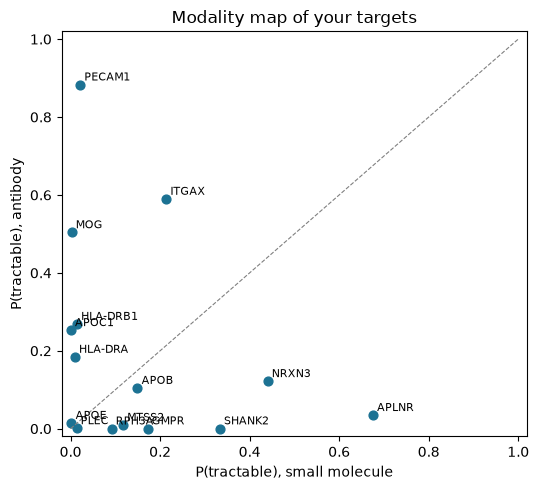

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(targets.p_sm, targets.p_ab, s=40, c="#1C7293")
for _, r in targets.iterrows():
    ax.annotate(r.gene, (r.p_sm, r.p_ab), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=0.8)
ax.set_xlabel("P(tractable), small molecule"); ax.set_ylabel("P(tractable), antibody")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_title("Modality map of your targets")
plt.tight_layout(); plt.show()

## Step 5 · Nearest known drug targets

For each target, the three most similar training-panel proteins **with clinical precedence**, with cosine similarity. This is the evidence behind each prior.

In [8]:
drugged = train[train["any_clinical"]].reset_index(drop=True)
X_drugged = X_train[train["any_clinical"].values]
S = cosine_matrix(X_targets, X_drugged)          # rows = your targets, columns = drugged proteins

# TODO: for each target, find the 3 most similar drugged proteins and store them as text
#       like "EGFR (0.81); ERBB2 (0.79); KIT (0.77)" in a new column `nearest_drug_targets`.
#       Hint: np.argsort(-S[i])[:3] gives the column indices of the 3 largest similarities in row i.
def top3(i):
    idx = np.argsort(-S[i])[:3]
    return "; ".join(f"{drugged.gene[j]} ({S[i, j]:.2f})" for j in idx)
targets["nearest_drug_targets"] = [top3(i) for i in range(len(targets))]

require(nearest_drug_targets=targets["nearest_drug_targets"].iloc[0])
targets[["gene", "p_sm", "p_ab", "nearest_drug_targets"]].round(2)

,gene,p_sm,p_ab,nearest_drug_targets
0,HLA-DRA,0.01,0.18,SEMA4D (0.92); GRIK3 (0.92); CA12 (0.91)
1,HLA-DRB1,0.01,0.27,SIGLEC8 (0.87); IFNA10 (0.86); PTGDS (0.85)
2,APOC1,0.00,0.25,IFNA5 (0.86); SCTR (0.85); SLC34A2 (0.85)
3,PECAM1,0.02,0.88,CD2 (0.96); IL12B (0.96); LAMA4 (0.95)
4,MTSS2,0.12,0.01,PDE4D (0.94); KCNQ4 (0.93); PDE4C (0.93)
5,ITGAX,0.21,0.59,ITGA2B (0.98); CSF1R (0.96); SEMA4D (0.95)
6,GMPR,0.17,0.00,EEF2 (0.95); PSMA5 (0.93); RPL11 (0.93)
7,RPH3A,0.09,0.00,CACNB3 (0.93); PDE4D (0.93); CACNB2 (0.92)
8,NRXN3,0.44,0.12,SDC4 (0.94); KCNB1 (0.93); RELA (0.92)
9,APLNR,0.68,0.03,AGTR2 (0.96); GHSR (0.95); S1PR2 (0.94)


## Step 6 · Anchor variants (required for everyone)

Report score and within-protein percentile for **APOE R176C (rs7412, ε2)**, **APOE C130R (rs429358, ε4)**, **TREM2 R47H**, and **one p53 hotspot** of your choice. UniProt numbering includes APOE's 18-residue signal peptide (mature names: R158C and C112R).

In [9]:
anchors = pd.read_csv(DATA / "anchor_variants.tsv", sep="\t")
print("Available anchor variants:")
print(anchors[["gene", "variant", "note"]].to_string(index=False))

P53_CHOICE = "R175H"    # TODO: pick one p53 hotspot from the table above

# TODO: build `my_anchors`, the four rows for APOE R176C, APOE C130R, TREM2 R47H, and your p53 choice.
wanted = [("APOE", "R176C"), ("APOE", "C130R"), ("TREM2", "R47H"), ("TP53", P53_CHOICE)]
my_anchors = pd.concat([anchors[(anchors.gene == g) & (anchors.variant == v)] for g, v in wanted])

require(my_anchors=my_anchors)
print(f"{len(my_anchors)} anchor variants selected")
my_anchors[["gene", "variant", "note", "score", "percentile_in_protein"]].round(2)

Available anchor variants:
 gene variant                                note
 TP53   R175H                             hotspot
 TP53   Y220C          hotspot, druggable crevice
 TP53   G245S                             hotspot
 TP53   R248Q                             hotspot
 TP53   R249S                             hotspot
 TP53   R273H                             hotspot
 TP53   R282W                             hotspot
 APOE   C130R rs429358, defines e4 (C112R mature)
 APOE   R176C   rs7412, defines e2 (R158C mature)
TREM2    R47H         rs75932628, AD risk variant
4 anchor variants selected


,gene,variant,note,score,percentile_in_protein
8,APOE,R176C,"rs7412, defines e2 (R158C mature)",-8.56,11.8
7,APOE,C130R,"rs429358, defines e4 (C112R mature)",7.21,100.0
9,TREM2,R47H,"rs75932628, AD risk variant",-5.16,47.7
0,TP53,R175H,hotspot,-5.97,19.3


## Step 7 · Re-rank and export

Combine your Module 2 evidence with the best-modality tractability prior. Choose the weight `w` (0 = tractability only, 1 = Module 2 only) and **justify it in your report**.

In [10]:
w = 0.6    # TODO: choose your weight and justify it in the report

targets["week2_pct"] = targets["score"].rank(pct=True)
targets["tract"] = targets[["p_sm", "p_ab"]].max(axis=1)

# TODO: compute `final` = w * week2_pct + (1 - w) * (percentile rank of tract), then `rank` (1 = best).
targets["final"] = w * targets["week2_pct"] + (1 - w) * targets["tract"].rank(pct=True)
targets["rank"] = targets["final"].rank(ascending=False, method="first").astype(int)

require(final=targets["final"].iloc[0], rank=targets["rank"].iloc[0])
out = (targets.rename(columns={"score": "week2_score"})
       [["rank", "gene", "week2_score", "p_sm", "p_ab", "nearest_drug_targets", "final"]]
       .sort_values("rank"))
out_file = f"targets_{DISEASE}_w3.csv"
out.round(4).to_csv(out_file, index=False)
print(f"Wrote {out_file} ({len(out)} targets). This is your hand-off to Week 4.")
out.round(3)

Wrote targets_ad_w3.csv (15 targets). This is your hand-off to Week 4.


,rank,gene,week2_score,p_sm,p_ab,nearest_drug_targets,final
3,1,PECAM1,0.939,0.021,0.883,CD2 (0.96); IL12B (0.96); LAMA4 (0.95),0.880
1,2,HLA-DRB1,0.955,0.014,0.269,SIGLEC8 (0.87); IFNA10 (0.86); PTGDS (0.85),0.800
0,3,HLA-DRA,0.957,0.010,0.184,SEMA4D (0.92); GRIK3 (0.92); CA12 (0.91),0.787
5,4,ITGAX,0.912,0.214,0.590,ITGA2B (0.98); CSF1R (0.96); SEMA4D (0.95),0.747
2,5,APOC1,0.949,0.001,0.253,IFNA5 (0.86); SCTR (0.85); SLC34A2 (0.85),0.733
9,6,APLNR,0.902,0.675,0.035,AGTR2 (0.96); GHSR (0.95); S1PR2 (0.94),0.613
8,7,NRXN3,0.904,0.440,0.122,SDC4 (0.94); KCNB1 (0.93); RELA (0.92),0.573
4,8,MTSS2,0.913,0.117,0.009,PDE4D (0.94); KCNQ4 (0.93); PDE4C (0.93),0.547
6,9,GMPR,0.910,0.172,0.000,EEF2 (0.95); PSMA5 (0.93); RPL11 (0.93),0.520
11,10,SHANK2,0.899,0.333,0.000,E2F7 (0.97); MAP3K13 (0.96); KCNQ3 (0.95),0.427


In [11]:
# Check: how did the ranking move? (useful for report question 1)
moved = targets.assign(week2_rank=targets["score"].rank(ascending=False, method="first").astype(int))
moved["change"] = moved["week2_rank"] - moved["rank"]
moved.sort_values("change")[["gene", "week2_rank", "rank", "change", "p_sm", "p_ab"]].round(2)

,gene,week2_rank,rank,change,p_sm,p_ab
7,RPH3A,8,12,-4,0.09,0.00
4,MTSS2,5,8,-3,0.12,0.01
0,HLA-DRA,1,3,-2,0.01,0.18
2,APOC1,3,5,-2,0.00,0.25
6,GMPR,7,9,-2,0.17,0.00
10,APOE,11,13,-2,0.00,0.01
12,APOB,13,14,-1,0.15,0.10
1,HLA-DRB1,2,2,0,0.01,0.27
14,PLEC,15,15,0,0.01,0.00
5,ITGAX,6,4,2,0.21,0.59


## Step 8 · Report (3–4 pages, the 40%)

Answer the five questions from the assignment sheet in your report (PDF), using the tables and plots above:

1. **Re-ranking.** Did the prior agree with your Module 2 ranking? Which target moved most, and why? Justify `w`.
2. **Modality.** Pick a target where `p_ab` and `p_sm` differ sharply and explain the biology.
3. **Validation.** Report your family-split metrics (Step 3). Why is this the honest number?
4. **Variants.** Interpret the anchor variant scores (Step 6). Why is a strongly negative score not the same as pathogenic, and what can these models not see?
5. **Limitations and next step.** What can sequence alone not tell you? Which two targets go to Week 4 for structure-based pocket assessment, and why?

Also list any **unmapped** genes from Step 1 and what kind of evidence they would need instead.